# Numerical extraction of quasi-normal excitation coefficients

In this notebook we develop a numerical algorithm to extract quasi-normal excitation coefficients (QNECs) directly from time-domain black-hole perturbation simulations.

The method is based on:

- numerical waveform generation,
- sliding-window QNM fitting,
- temporal alignment,
- ensemble averaging over fitting windows,
- statistical extraction of amplitudes and phases.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from joblib import Parallel, delayed

import qnm
import rw_solver as rw

plt.rcParams['text.usetex'] = True

## Global setup

Here we define the main physical and numerical parameters used in the analysis. This includes the black hole parameters, the Gaussian initial perturbation, the simulation grid, and the QNM frequencies used in the ringdown fits. In this example we keep the Gaussian width $\sigma$ fixed and vary the oscillation frequency $\nu$ of the initial data.

In [60]:
ell = 2  # mode

# black hole and perturbation parameters
Mbh          = 1.0
l_mode_l2    = ell
m_mode_l2    = 0

A_init_l2    = 1.0      # initial data amplitude
r0_l2        = 100.0    # initial data position
r_obs_target_l2 = 100.0 # observer position

# simulation grid
x_min, x_max = -200.0, 1500.0
Ngrid        = 8000
TF           = 500.0
CFL          = 0.1

# peak search interval
t_search_min = 195.0
t_search_max = 205.0

# qnm modes used in the fit
n_list = [0]
modes_l2 = [(l_mode_l2, m_mode_l2, n, 1) for n in n_list]

def get_qnm_omegas(ell, m_q, n_list, chif=0.0, Mf=1.0, s_spin=-2):
    omegas = []
    for n in n_list:
        mode = qnm.modes_cache(s=s_spin, l=ell, m=m_q, n=n)
        w, _, _ = mode(a=chif)
        omegas.append(w / Mf)
    return np.array(omegas, dtype=complex)

omegas_l2 = get_qnm_omegas(l_mode_l2, m_mode_l2, n_list)
N_modes_l2 = len(omegas_l2)

print(f"[l={ell}] loaded modes: {modes_l2}")
print(f"[l={ell}] qnm frequencies (M=1): {omegas_l2}")

# sliding fit parameters
T_window = 100.0   # fit window length
dt_scan  = 0.07   # sliding step
min_pts  = 20     # minimum points per window

# fixed sigma, sweep over nu
sigma_l2 = 5.0

nu_min, nu_max, dnu = 0.0, 1.0, 0.001
nu_grid_l2 = np.arange(nu_min, nu_max + dnu, dnu)
n_nu_l2 = len(nu_grid_l2)

print(f"[l={ell}] sweep over nu: {n_nu_l2} values in [{nu_min}, {nu_max}] with step {dnu}")
print(f"[l={ell}] fixed sigma = {sigma_l2}")

# parallelization
N_JOBS = 7

[l=2] loaded modes: [(2, 0, 0, 1)]
[l=2] qnm frequencies (M=1): [0.37367168-0.08896232j]
[l=2] sweep over nu: 1001 values in [0.0, 1.0] with step 0.001
[l=2] fixed sigma = 5.0


## Numerical simulations

For each value of $\nu$, we evolve the Gaussian initial perturbation using the Regge--Wheeler solver and extract the waveform at the observer location. The peak of the signal is identified considering the propagation time, and all waveforms are shifted so that their peaks are aligned at $t=0$. This provides a common temporal reference frame for the QNM analysis and the sliding fits performed in the following sections.

[l=2] Lanzando 1001 simulaciones (sigma=5.0)...


/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/uib/Desktop/examples/rw_solver.py:17: RuntimeWarning: overflow encountered in exp
  z = np.exp(s/(2.0*M) - 1.0)
/Users/uib/D

[l=2] Simulaciones completadas: 1001 waveforms.


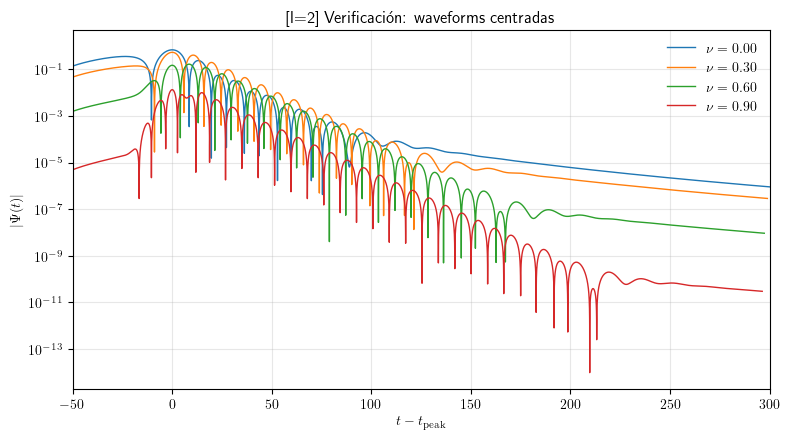

In [ ]:
def run_one_simulation_l2(nu):
    # initial data
    Psi0 = rw.gaussiana(
        A_init_l2, x_min, x_max, Ngrid,
        nu, r0_l2, sigma_l2
    )

    # evolution
    U, T, s_grid = rw.simula_full(
        N=Ngrid, x_min=x_min, x_max=x_max,
        Psi_initial=Psi0, TF=TF, CFL=CFL,
        l=l_mode_l2, M=Mbh
    )

    # waveform at the observer
    wf = rw.extract_observer_4th(U, s_grid, r_obs_target_l2)
    del U  # free memory

    # peak inside the physical window
    abs_wf = np.abs(wf)
    mask = (T >= t_search_min) & (T <= t_search_max)

    if not np.any(mask):
        raise RuntimeError(
            f"no points in [{t_search_min}, {t_search_max}] for nu={nu}"
        )

    i_peak = np.where(mask)[0][np.argmax(abs_wf[mask])]
    t_peak = T[i_peak]

    # center the waveform at the peak
    t_centered = T - t_peak
    Psi_t = np.real(wf)

    return nu, t_centered, Psi_t, t_peak


# parallel execution over nu
print(f"launching {n_nu_l2} simulations (sigma={sigma_l2})...")

waveforms_raw_l2 = Parallel(n_jobs=N_JOBS)(
    delayed(run_one_simulation_l2)(nu)
    for nu in nu_grid_l2
)

# dictionary indexed by nu
waveforms_l2 = {
    nu: {'t_centered': t_c, 'Psi_t': psi, 't_peak': tp}
    for (nu, t_c, psi, tp) in waveforms_raw_l2
}

print(f"completed simulations: {len(waveforms_l2)} waveforms.")


# quick verification
fig, ax = plt.subplots()

for nu_check in [0.0, 0.3, 0.6, 0.9]:
    idx = np.argmin(np.abs(nu_grid_l2 - nu_check))
    nu_real = nu_grid_l2[idx]

    d = waveforms_l2[nu_real]
    ax.plot(d['t_centered'], np.abs(d['Psi_t']),
            lw=1.0, label=fr'$\nu = {nu_real:.2f}$')

ax.set_yscale('log')
ax.set_xlabel(r'$t - t_{\rm peak}$')
ax.set_ylabel(r'$|\Psi(t)|$')
ax.set_xlim(-50, 300)
ax.grid(True)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# save results
save_data_l2 = {
    'waveforms_l2': waveforms_l2,
    'nu_grid_l2': nu_grid_l2,
    'sigma_l2': sigma_l2,
    'params': {
        'Ngrid': Ngrid,
        'TF': TF,
        'CFL': CFL,
        'l_mode_l2': l_mode_l2,
        'Mbh': Mbh,
        'r_obs_target_l2': r_obs_target_l2,
        'r0_l2': r0_l2,
        't_search_min': t_search_min,
        't_search_max': t_search_max
    }
}

with open("waveforms_l2_nu_scan.pkl", "wb") as f:
    pickle.dump(save_data_l2, f)

print("results saved in waveforms_l2_nu_scan.pkl")

## Loading the data

In [61]:
with open("waveforms_l2_nu_scan.pkl", "rb") as f:
    data_l2 = pickle.load(f)

waveforms_l2 = data_l2['waveforms_l2']
nu_grid_l2 = data_l2['nu_grid_l2']
sigma_l2 = data_l2['sigma_l2']

print(f"loaded waveforms: {len(waveforms_l2)}")
print(f"fixed sigma: {sigma_l2}")
print(f"number of nu values: {len(nu_grid_l2)}")

loaded waveforms: 1001
fixed sigma: 5.0
number of nu values: 1001


## Waveform alignment and peak diagnostics

reference t_peak = 202.034 [M]
t_peak min = 199.945 [M]
t_peak max = 203.983 [M]
range = 4.038 [M]


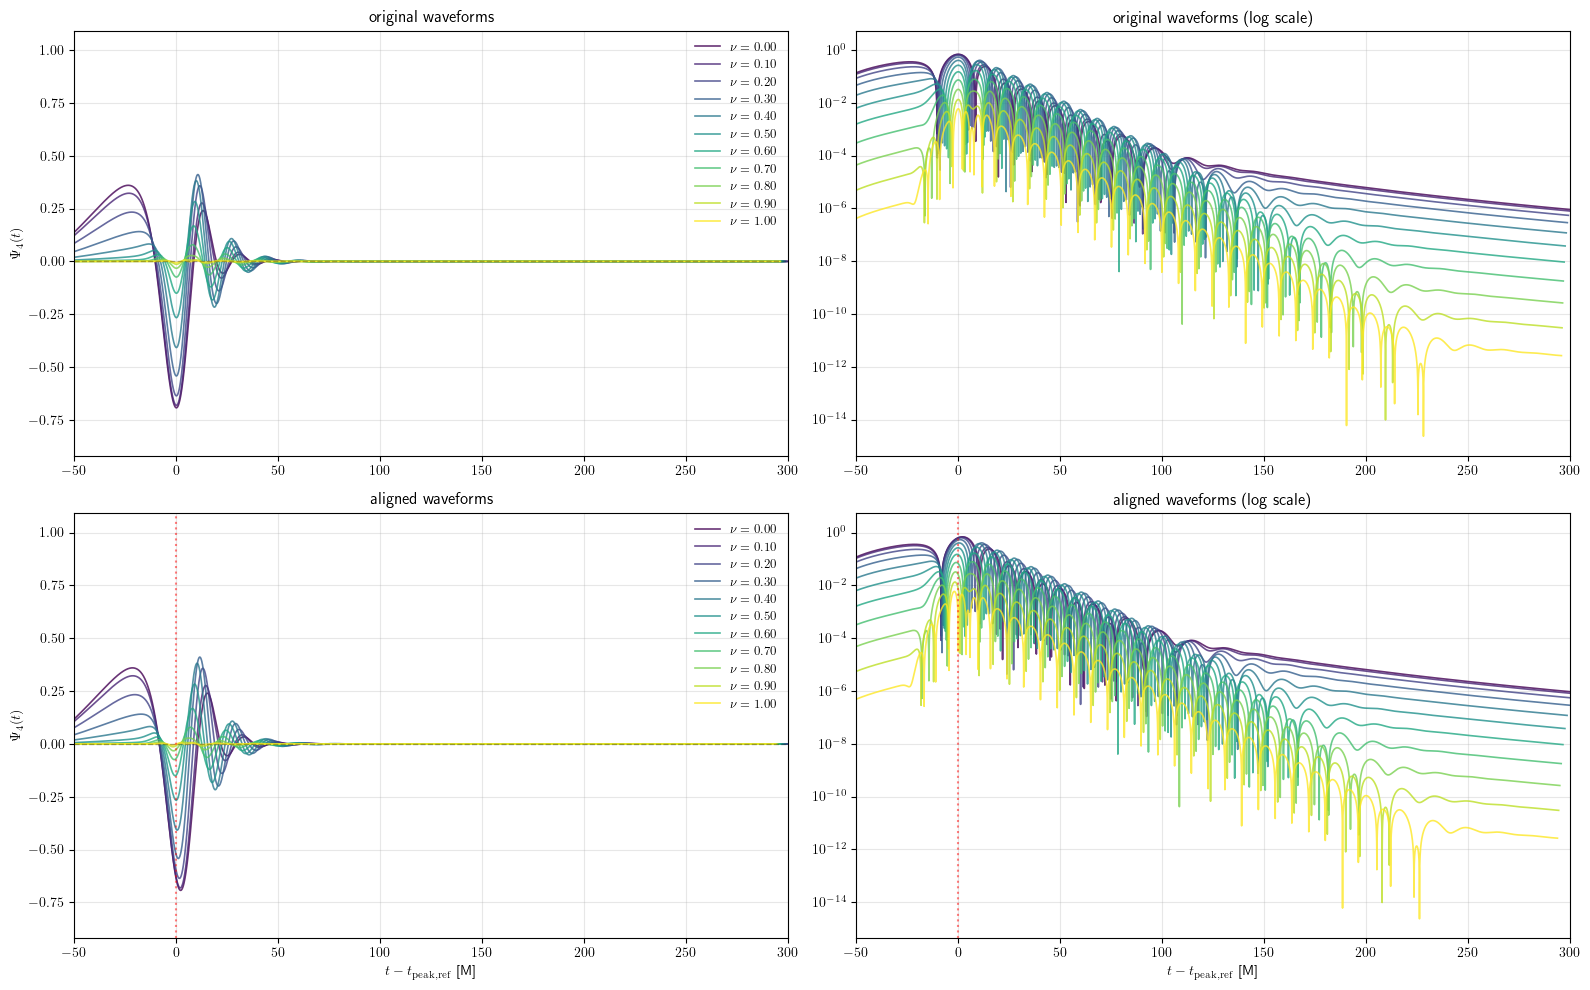

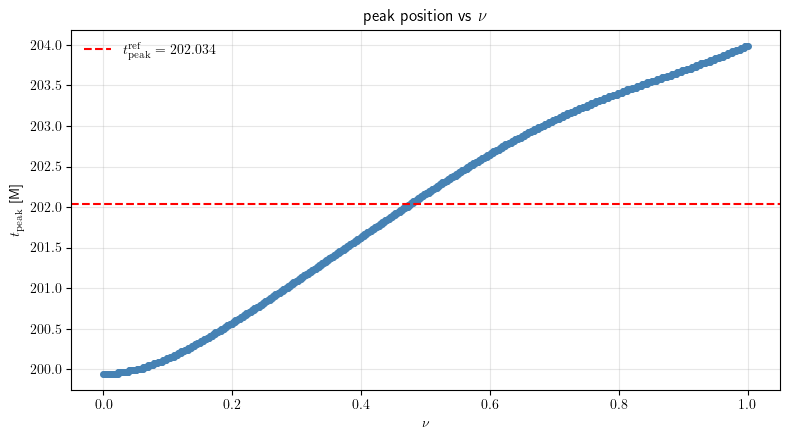

In [63]:
# subset of waveforms to visualize
nu_subset = np.arange(0.0, 1.0 + 0.05, 0.1)
colors = plt.cm.viridis(np.linspace(0, 1, len(nu_subset)))

# peak times
t_peaks = np.array([
    waveforms_l2[nu]['t_peak']
    for nu in nu_grid_l2
])

# common reference peak
t_peak_ref = np.mean(t_peaks)

print(f"reference t_peak = {t_peak_ref:.3f} [M]")
print(f"t_peak min = {t_peaks.min():.3f} [M]")
print(f"t_peak max = {t_peaks.max():.3f} [M]")
print(f"range = {t_peaks.max() - t_peaks.min():.3f} [M]")

# ============================================================
# plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

# ------------------------------------------------------------
# original centered waveforms
# ------------------------------------------------------------
for nu_val, color in zip(nu_subset, colors):

    idx = np.argmin(np.abs(nu_grid_l2 - nu_val))
    nu_real = nu_grid_l2[idx]

    d = waveforms_l2[nu_real]

    t_c = d['t_centered']
    psi = d['Psi_t']

    label = fr'$\nu = {nu_real:.2f}$'

    ax1.plot(
        t_c, psi,
        lw=1.2, color=color, alpha=0.8,
        label=label
    )

    ax2.semilogy(
        t_c, np.abs(psi),
        lw=1.2, color=color, alpha=0.8,
        label=label
    )

# ------------------------------------------------------------
# aligned waveforms using common t_peak
# ------------------------------------------------------------
for nu_val, color in zip(nu_subset, colors):

    idx = np.argmin(np.abs(nu_grid_l2 - nu_val))
    nu_real = nu_grid_l2[idx]

    d = waveforms_l2[nu_real]

    t_c = d['t_centered']
    psi = d['Psi_t']

    delta_t = d['t_peak'] - t_peak_ref
    t_aligned = t_c - delta_t

    label = fr'$\nu = {nu_real:.2f}$'

    ax3.plot(
        t_aligned, psi,
        lw=1.2, color=color, alpha=0.8,
        label=label
    )

    ax4.semilogy(
        t_aligned, np.abs(psi),
        lw=1.2, color=color, alpha=0.8,
        label=label
    )

# ------------------------------------------------------------
# style
# ------------------------------------------------------------
for ax in [ax1, ax3]:
    ax.axhline(0, color='black', ls='--', alpha=0.3, lw=1)
    ax.set_xlim(-50, 300)
    ax.grid(alpha=0.3)

for ax in [ax2, ax4]:
    ax.set_xlim(-50, 300)
    ax.grid(alpha=0.3, which='both')

ax3.axvline(0, color='red', ls=':', alpha=0.5, lw=1.5)
ax4.axvline(0, color='red', ls=':', alpha=0.5, lw=1.5)

# labels
ax1.set_title('original waveforms')
ax2.set_title('original waveforms (log scale)')
ax3.set_title('aligned waveforms')
ax4.set_title('aligned waveforms (log scale)')

ax1.set_ylabel(r'$\Psi_4(t)$')
ax3.set_ylabel(r'$\Psi_4(t)$')

ax3.set_xlabel(r'$t - t_{\rm peak,ref}$ [M]')
ax4.set_xlabel(r'$t - t_{\rm peak,ref}$ [M]')

# legends
ax1.legend(frameon=False, fontsize=9)
ax3.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# t_peak vs nu
# ============================================================
fig_peak, ax_peak = plt.subplots(figsize=(8, 4.5))

ax_peak.plot(
    nu_grid_l2, t_peaks,
    'o-', lw=2, ms=4,
    color='steelblue'
)

ax_peak.axhline(
    t_peak_ref,
    color='red',
    ls='--',
    lw=1.5,
    label=fr'$t_{{\rm peak}}^{{\rm ref}} = {t_peak_ref:.3f}$'
)

ax_peak.set_xlabel(r'$\nu$')
ax_peak.set_ylabel(r'$t_{\rm peak}$ [M]')
ax_peak.set_title(r'peak position vs $\nu$')
ax_peak.grid(alpha=0.3)
ax_peak.legend(frameon=False)

plt.tight_layout()
plt.show()

## Sliding QNM fits

We apply sliding-window QNM fits to all waveforms. For each time window, the waveform is fitted using the chosen QNM frequencies, producing a set of complex coefficients $C_n(t_0)$ as functions of the starting time of the window.

launching fits for 1001 waveforms...
completed fits: 1001 curves.


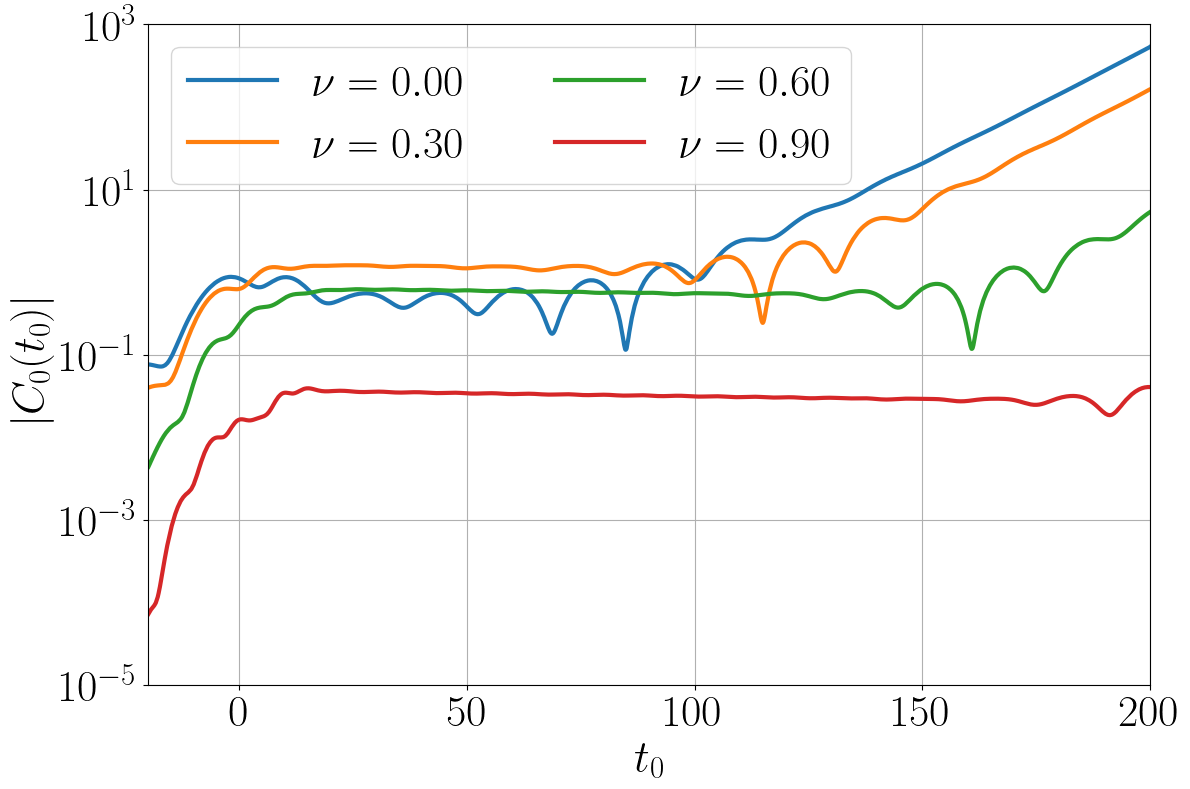

In [ ]:
# ============================================================
# cell 2 — sliding qnm fit
# ============================================================

# sliding fit parameters
T_window = 10.0
dt_scan  = 0.07
min_pts  = 20

def sequential_window_fit(t, data, omegas, T_window, dt_scan, min_pts=20):

    t = np.asarray(t)
    data = np.asarray(data, dtype=float)
    omegas = np.asarray(omegas, dtype=complex)

    t0_values = np.arange(t.min(), t.max() - T_window, dt_scan)

    t0_list = []
    C_lists = [[] for _ in omegas]

    for t0 in t0_values:

        # current window
        mask = (t >= t0) & (t <= t0 + T_window)

        Tw = t[mask]
        Yw = data[mask]

        if len(Tw) < min_pts:
            continue

        # residual waveform
        Y_res = Yw.copy()

        for i, omega in enumerate(omegas):

            X = np.exp(-1j * omega * Tw)

            # linear fit
            M = np.column_stack([np.real(X), -np.imag(X)])
            theta, *_ = np.linalg.lstsq(M, Y_res, rcond=None)

            Ci = theta[0] + 1j*theta[1]

            C_lists[i].append(Ci)

            # subtract mode
            Y_res = Y_res - np.real(Ci * X)

        t0_list.append(t0)

    return np.asarray(t0_list), np.array(C_lists).T

# fit one waveform
def fit_one_waveform_l2(nu, d):

    t0_arr, C_matrix = sequential_window_fit(
        d['t_centered'], d['Psi_t'], omegas_l2,
        T_window=T_window, dt_scan=dt_scan,
        min_pts=min_pts
    )

    return nu, t0_arr, C_matrix

print(f"launching fits for {len(waveforms_l2)} waveforms...")

# parallel execution
fits_raw_l2 = Parallel(n_jobs=N_JOBS)(
    delayed(fit_one_waveform_l2)(nu, waveforms_l2[nu])
    for nu in nu_grid_l2
)

# dictionary indexed by nu
fits_l2 = {
    nu: {'t0_arr': t0_arr, 'C_matrix': C_matrix}
    for (nu, t0_arr, C_matrix) in fits_raw_l2
}

print(f"completed fits: {len(fits_l2)} curves.")

# ============================================================
# verification plot
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

for nu_check in [0.0, 0.3, 0.6, 0.9]:

    idx = np.argmin(np.abs(nu_grid_l2 - nu_check))
    nu_real = nu_grid_l2[idx]

    f = fits_l2[nu_real]
    abs_C0 = np.abs(f['C_matrix'][:, 0])

    ax.plot(f['t0_arr'], abs_C0, lw=3,
            label=fr'$\nu = {nu_real:.2f}$')

# style
ax.set_xlabel(r'$t_0$', fontsize=32)
ax.set_ylabel(r'$|C_0(t_0)|$', fontsize=32)
ax.set_xlim(-20, 200)
ax.set_ylim(1e-5, 1e3)
ax.set_yscale('log')
ax.tick_params(labelsize=32)
ax.grid(True)
ax.legend(fontsize=32, frameon=True,loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

## Window scan and temporal correction

We now average the fitted coefficients over many fitting windows. Each window is defined by a starting and ending time $(t_0^{\min}, t_0^{\max})$. The resulting matrices contain the complex QNM amplitudes for all values of $\nu$ and all fitting windows. We then apply the temporal correction that maps all waveforms to the same reference peak time.

window pairs: 1485

temporal information:
  t_peak_ref = 202.034 [M]
  t_peak range = [199.945, 203.983]
  total variation = 4.038 [M]

qnm frequency:
  ω_0 = 0.373672 - i 0.088962

matrices constructed:
  shape = (1001, 1485)
  nan fraction = 0.00%

temporal correction applied.
  common reference = t_peak_ref


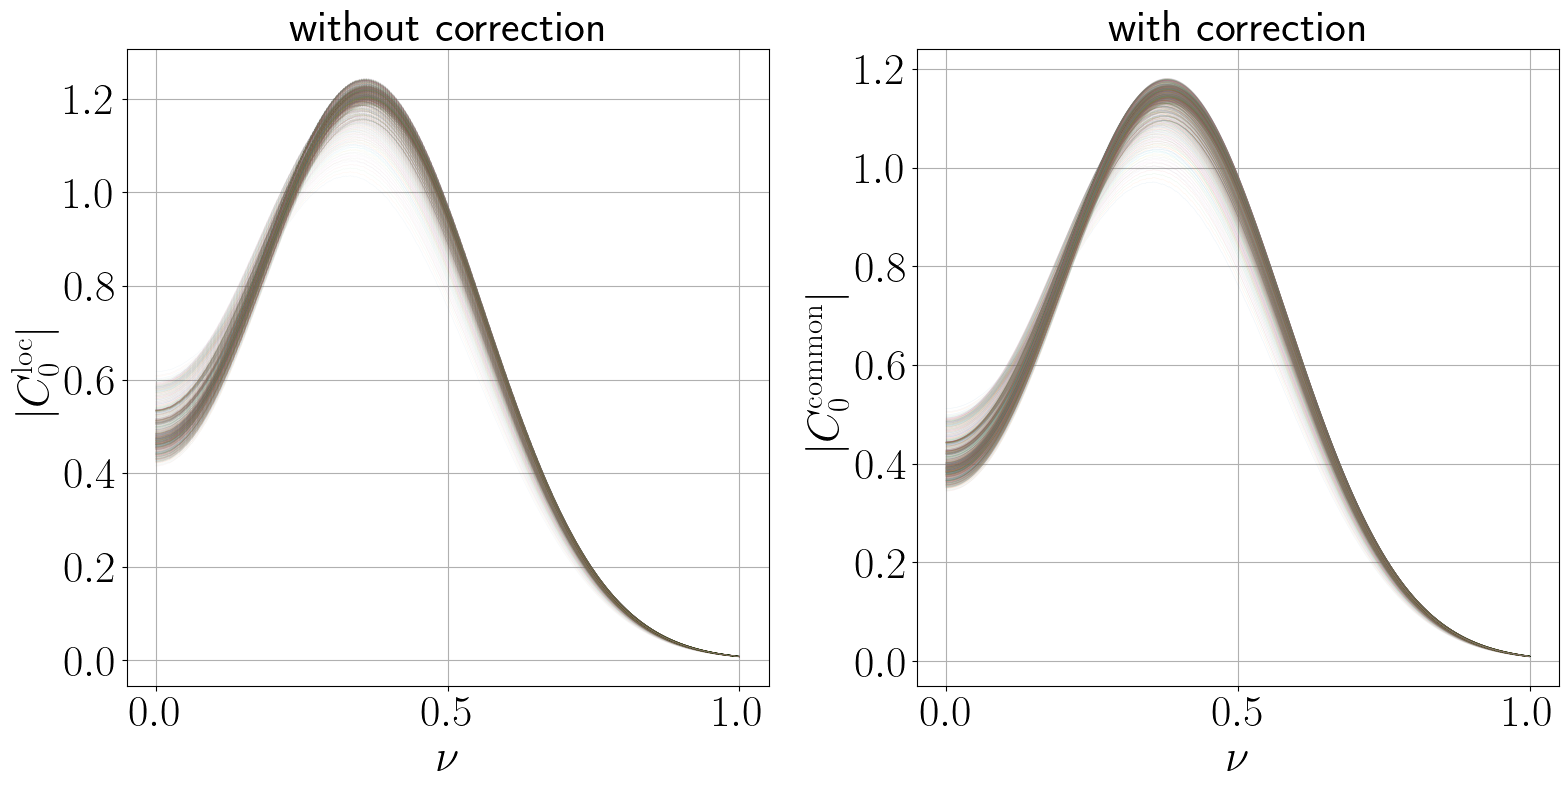

In [86]:
# ============================================================
# cell 3 — window scan
# ============================================================

# window grid
t0_min_grid = np.arange(0, 45, 1)
t0_max_grid = np.arange(15, 75, 1)

# valid windows
TMN, TMX = np.meshgrid(t0_min_grid, t0_max_grid, indexing='ij')

mask_valid = (TMX > TMN) & ((TMX - TMN) >= 20)

tmn_arr = TMN[mask_valid].astype(float)
tmx_arr = TMX[mask_valid].astype(float)

duration_arr = tmx_arr - tmn_arr

n_windows = len(tmn_arr)

print(f"window pairs: {n_windows}")

# temporal information
t_peak_array = np.array(
    [waveforms_l2[nu]['t_peak'] for nu in nu_grid_l2],
    dtype=float
)

t_peak_ref = np.mean(t_peak_array)

print(f"\ntemporal information:")
print(f"  t_peak_ref = {t_peak_ref:.3f} [M]")
print(f"  t_peak range = [{t_peak_array.min():.3f}, {t_peak_array.max():.3f}]")
print(f"  total variation = {(t_peak_array.max()-t_peak_array.min()):.3f} [M]")

omega_0 = omegas_l2[0]

print(f"\nqnm frequency:")
print(f"  ω_0 = {omega_0.real:.6f} - i {abs(omega_0.imag):.6f}")

# matrices
abs_C0_matrix_l2 = np.full((n_nu_l2, n_windows), np.nan, dtype=float)

C0_complex_matrix_l2 = np.full(
    (n_nu_l2, n_windows),
    np.nan + 0j,
    dtype=complex
)

# compute window averages
for nu_idx, nu in enumerate(nu_grid_l2):

    f = fits_l2[nu]

    t0_arr = np.asarray(f['t0_arr'], dtype=float)
    C0_arr = np.asarray(f['C_matrix'][:, 0], dtype=complex)

    # cumulative sum
    csum = np.concatenate([[0.0 + 0.0j], np.cumsum(C0_arr)])

    # fast indices
    i0 = np.searchsorted(t0_arr, tmn_arr, side='left')
    i1 = np.searchsorted(t0_arr, tmx_arr, side='right')

    counts = i1 - i0
    valid = counts > 0

    # window means
    sums = csum[i1] - csum[i0]

    means = np.full(n_windows, np.nan + 0j, dtype=complex)

    means[valid] = sums[valid] / counts[valid]

    # store
    C0_complex_matrix_l2[nu_idx, :] = means
    abs_C0_matrix_l2[nu_idx, :] = np.abs(means)

print(f"\nmatrices constructed:")
print(f"  shape = {abs_C0_matrix_l2.shape}")
print(f"  nan fraction = {np.mean(np.isnan(abs_C0_matrix_l2)):.2%}")

# temporal correction
phase_shifts = np.exp(1j * omega_0 * (t_peak_array - t_peak_ref))

C0_common_matrix_l2 = (
    C0_complex_matrix_l2 *
    phase_shifts[:, None]
)

print(f"\ntemporal correction applied.")
print(f"  common reference = t_peak_ref")

# ============================================================
# verification plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# without correction
ax1.plot(nu_grid_l2[:, None],abs_C0_matrix_l2,alpha=0.05,lw=0.4)

# with correction
ax2.plot(nu_grid_l2[:, None],np.abs(C0_common_matrix_l2),alpha=0.08,lw=0.4)

# style
for ax in [ax1, ax2]:
    ax.set_xlabel(r'$\nu$', fontsize=32)
    ax.tick_params(labelsize=32)
    ax.grid(True)

ax1.set_ylabel(r'$|C_0^{\rm loc}|$', fontsize=32)
ax2.set_ylabel(r'$|C_0^{\rm common}|$', fontsize=32)

ax1.set_title(r'without correction', fontsize=32)
ax2.set_title(r'with correction', fontsize=32)

plt.tight_layout()
plt.show()

## Window filtering

In principle, one can remove fitting windows that are too short or extend outside the desired ringdown region in order to suppress contamination from the prompt response and late-time tails. In this example, however, we keep the full set of windows and apply the temporal correction directly to all fitted coefficients.

filtering: 1485 / 1485 windows (100.0%)
criteria: duration ≥ 20, t0_min ≥ 0, t0_max ≤ 75


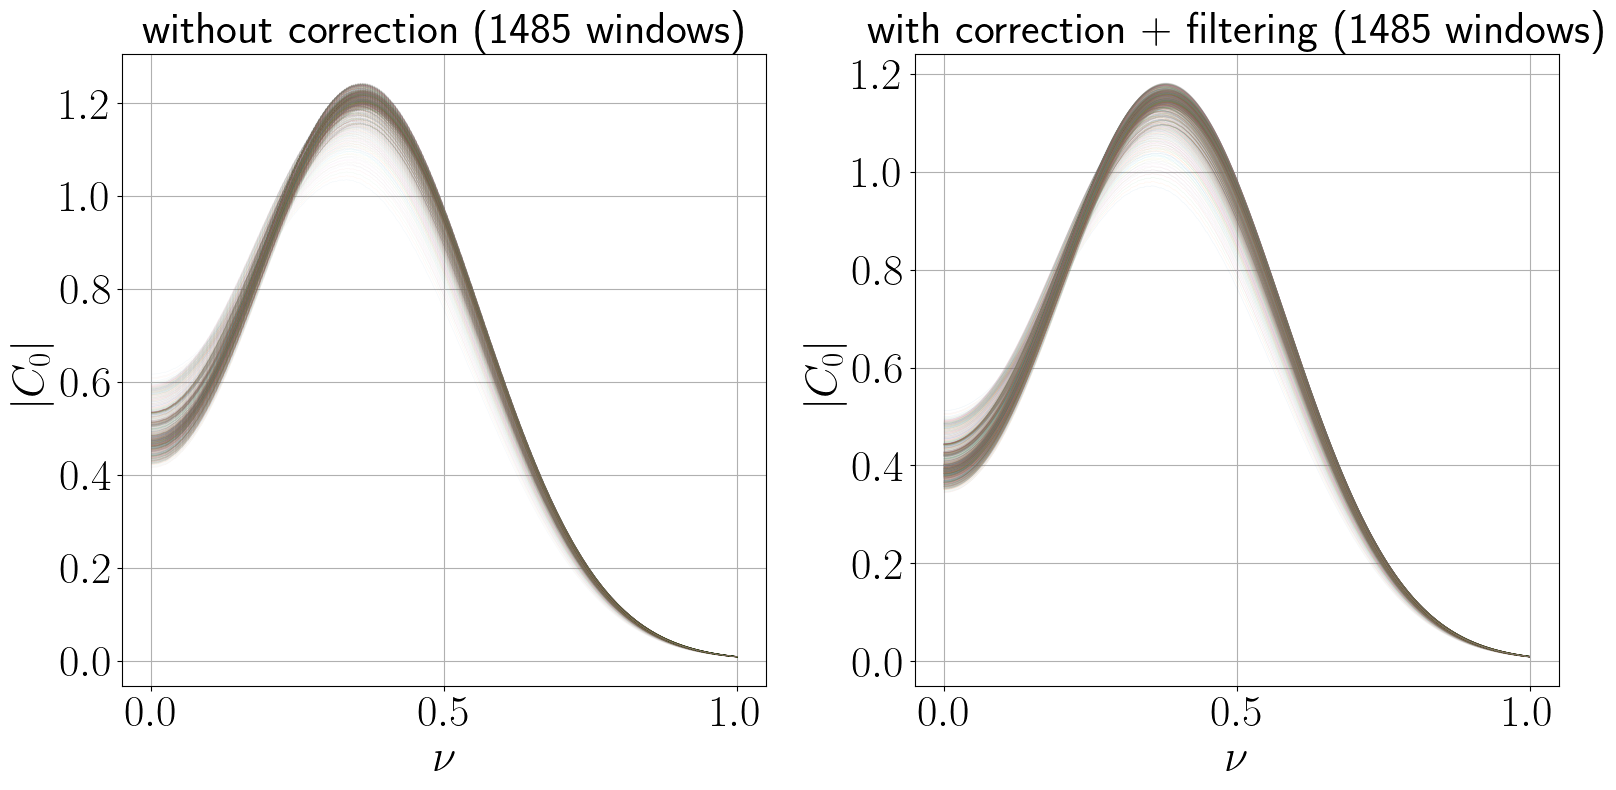

In [89]:
# filter thresholds
MIN_DURATION = 20
MIN_T0       = 0
MAX_T1       = 75

# mask
keep = (
    (duration_arr >= MIN_DURATION) &
    (tmn_arr >= MIN_T0) &
    (tmx_arr <= MAX_T1)
)

# nan filter
nan_frac_per_window = np.mean(np.isnan(np.abs(C0_common_matrix_l2)),axis=0)

keep &= (nan_frac_per_window < 0.05)

n_keep = int(keep.sum())

print(f"filtering: {n_keep} / {n_windows} windows ({n_keep/n_windows:.1%})")

print(
    f"criteria: duration ≥ {MIN_DURATION}, "
    f"t0_min ≥ {MIN_T0}, t0_max ≤ {MAX_T1}"
)

window_pairs_arr = np.column_stack([tmn_arr, tmx_arr])

# filtered matrices
abs_C0_filt_l2 = np.abs(C0_common_matrix_l2[:, keep])
C0_complex_filt_l2 = C0_common_matrix_l2[:, keep]
window_pairs_filt_l2 = window_pairs_arr[keep]

# ============================================================
# verification plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# without correction
ax1.plot(nu_grid_l2[:, None], abs_C0_matrix_l2, alpha=0.05, lw=0.4)

# with correction + filtering
ax2.plot(nu_grid_l2[:, None], abs_C0_filt_l2, alpha=0.08, lw=0.4)

# style
for ax in [ax1, ax2]:
    ax.set_xlabel(r'$\nu$', fontsize=32)
    ax.tick_params(labelsize=32)
    ax.grid(True)

ax1.set_ylabel(r'$|C_0|$', fontsize=32)
ax2.set_ylabel(r'$|C_0|$', fontsize=32)

ax1.set_title(rf'without correction ({n_windows} windows)', fontsize=32)
ax2.set_title(rf'with correction + filtering ({n_keep} windows)', fontsize=32)

plt.tight_layout()
plt.show()

## Statistics and temporal correction comparison

We now compute the statistical properties of the fitted amplitudes as functions of $\nu$. We compare the results obtained before and after applying the temporal correction.


peak comparison:
  ω_0^R = 0.373672 [M^-1]

without temporal correction:
  ν_peak = 0.3570
  |C_0| = 1.208811
  Δν = -0.016672

with temporal correction:
  ν_peak = 0.3800
  |C_0^common| = 1.147524
  Δν = 0.006328

peak shift = -0.023000


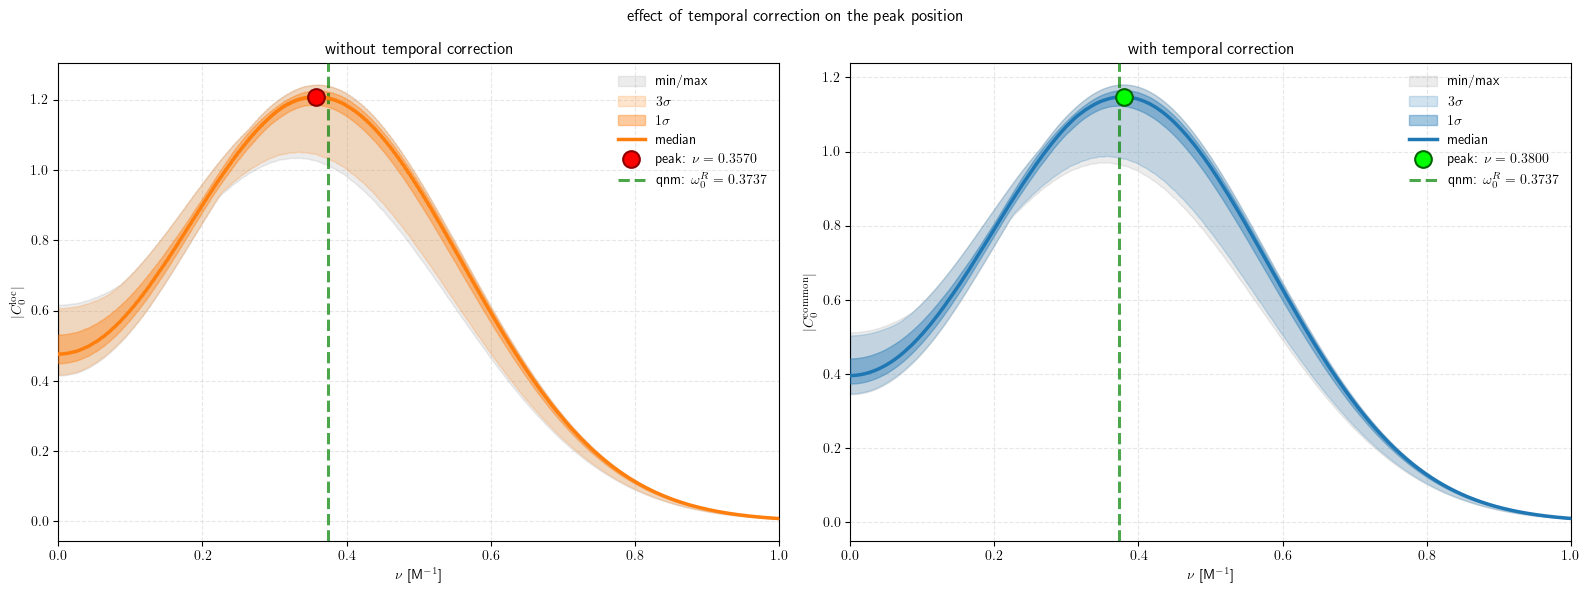

In [ ]:
plt.rcParams['text.usetex'] = True

# ============================================================
# corrected statistics
# ============================================================
median_C0_l2 = np.nanmedian(abs_C0_filt_l2, axis=1)

p1s_lo_l2 = np.nanpercentile(abs_C0_filt_l2, 15.865, axis=1)
p1s_hi_l2 = np.nanpercentile(abs_C0_filt_l2, 84.135, axis=1)

p3s_lo_l2 = np.nanpercentile(abs_C0_filt_l2, 0.135, axis=1)
p3s_hi_l2 = np.nanpercentile(abs_C0_filt_l2, 99.865, axis=1)

env_min_l2 = np.nanmin(abs_C0_filt_l2, axis=1)
env_max_l2 = np.nanmax(abs_C0_filt_l2, axis=1)

# corrected peak
idx_peak = np.nanargmax(median_C0_l2)

peak_value = median_C0_l2[idx_peak]

nu_peak = nu_grid_l2[idx_peak]

band_width = p1s_hi_l2[idx_peak] - p1s_lo_l2[idx_peak]

# ============================================================
# uncorrected statistics
# ============================================================
abs_C0_uncorr_l2 = abs_C0_matrix_l2

median_C0_uncorr = np.nanmedian(abs_C0_uncorr_l2, axis=1)

p1s_lo_uncorr = np.nanpercentile(abs_C0_uncorr_l2, 15.865, axis=1)
p1s_hi_uncorr = np.nanpercentile(abs_C0_uncorr_l2, 84.135, axis=1)

p3s_lo_uncorr = np.nanpercentile(abs_C0_uncorr_l2, 0.135, axis=1)
p3s_hi_uncorr = np.nanpercentile(abs_C0_uncorr_l2, 99.865, axis=1)

env_min_uncorr = np.nanmin(abs_C0_uncorr_l2, axis=1)
env_max_uncorr = np.nanmax(abs_C0_uncorr_l2, axis=1)

# uncorrected peak
idx_peak_uncorr = np.nanargmax(median_C0_uncorr)

nu_peak_uncorr = nu_grid_l2[idx_peak_uncorr]

peak_value_uncorr = median_C0_uncorr[idx_peak_uncorr]

# qnm frequency
nu_qnm = omega_0.real

# diagnostics
print("\npeak comparison:")

print(f"  ω_0^R = {nu_qnm:.6f} [M^-1]")

print("\nwithout temporal correction:")

print(f"  ν_peak = {nu_peak_uncorr:.4f}")
print(f"  |C_0| = {peak_value_uncorr:.6f}")
print(f"  Δν = {(nu_peak_uncorr - nu_qnm):.6f}")

print("\nwith temporal correction:")

print(f"  ν_peak = {nu_peak:.4f}")
print(f"  |C_0^common| = {peak_value:.6f}")
print(f"  Δν = {(nu_peak - nu_qnm):.6f}")

print(f"\npeak shift = {(nu_peak_uncorr - nu_peak):.6f}")

# ============================================================
# comparison plot
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# without correction
ax1.fill_between(nu_grid_l2, env_min_uncorr, env_max_uncorr, color='gray', alpha=0.15)
ax1.fill_between(nu_grid_l2, p3s_lo_uncorr, p3s_hi_uncorr, alpha=0.20)
ax1.fill_between(nu_grid_l2, p1s_lo_uncorr, p1s_hi_uncorr, alpha=0.40)

ax1.plot(nu_grid_l2, median_C0_uncorr, lw=3)

ax1.axvline(nu_qnm, linestyle='--', lw=3)

# with correction
ax2.fill_between(nu_grid_l2, env_min_l2, env_max_l2, color='gray', alpha=0.15)
ax2.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2, alpha=0.20)
ax2.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2, alpha=0.40)

ax2.plot(nu_grid_l2, median_C0_l2, lw=3)

ax2.axvline(nu_qnm, linestyle='--', lw=3)

# style
for ax in [ax1, ax2]:
    ax.set_xlabel(r'$\nu$', fontsize=32)
    ax.tick_params(labelsize=32)
    ax.grid(True)

ax1.set_ylabel(r'$|C_0^{\rm loc}|$', fontsize=32)
ax2.set_ylabel(r'$|C_0^{\rm common}|$', fontsize=32)

ax1.set_title(r'without correction', fontsize=32)
ax2.set_title(r'with correction', fontsize=32)

plt.tight_layout()
plt.show()

In [ ]:
# Copy uncorrected statistics from CELL 5B
# (make sure CELL 5B has been executed beforehand)
if 'median_C0_uncorr' not in locals():
    median_C0_uncorr = np.nanmedian(abs_C0_matrix_l2, axis=1)
    p1s_lo_uncorr = np.nanpercentile(abs_C0_matrix_l2, 15.865, axis=1)
    p1s_hi_uncorr = np.nanpercentile(abs_C0_matrix_l2, 84.135, axis=1)
    p3s_lo_uncorr = np.nanpercentile(abs_C0_matrix_l2,  0.135, axis=1)
    p3s_hi_uncorr = np.nanpercentile(abs_C0_matrix_l2, 99.865, axis=1)
    env_min_uncorr = np.nanmin(abs_C0_matrix_l2, axis=1)
    env_max_uncorr = np.nanmax(abs_C0_matrix_l2, axis=1)

## Phase statistics

We now compute the phase statistics of the complex QNM amplitudes as functions of $\nu$. Circular statistics and phase unwrapping are used to remove artificial $\pm \pi$ discontinuities.

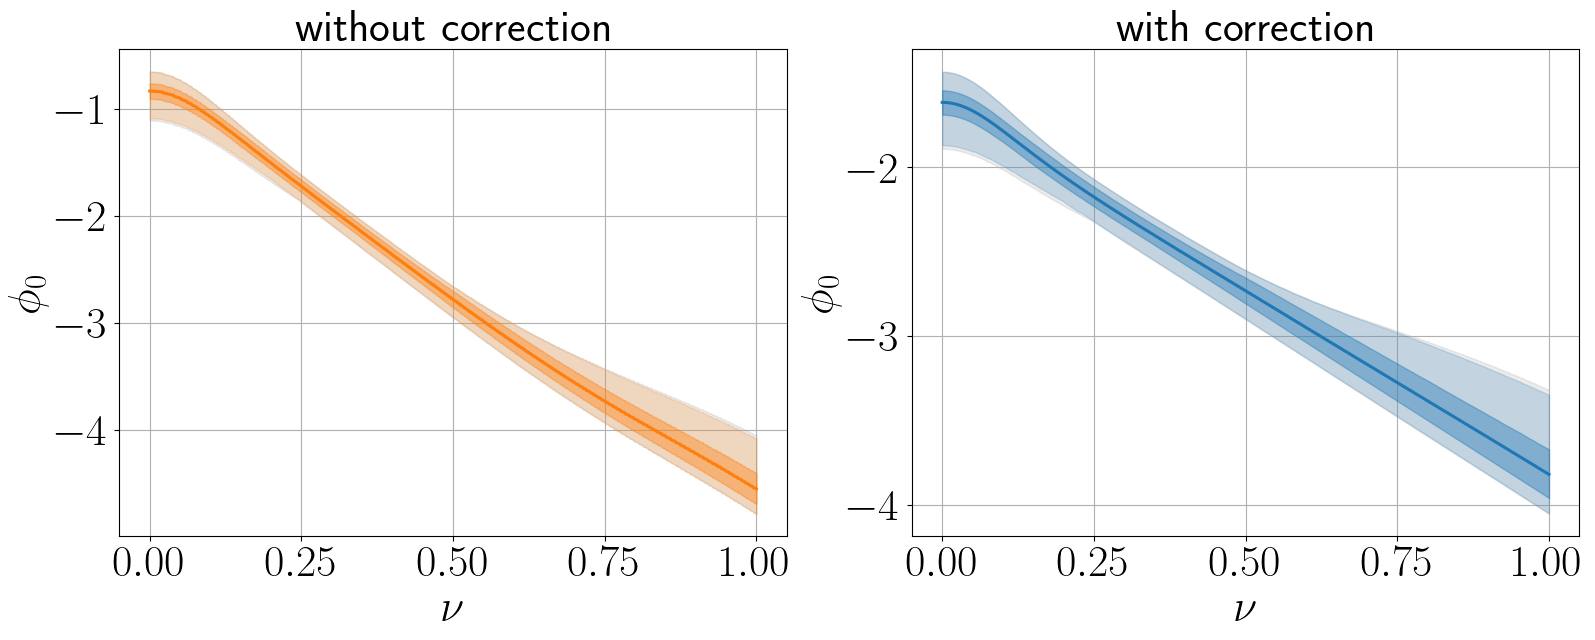

In [92]:
# circular statistics
def circ_stats(M):

    phases = np.angle(M)

    mean_complex = np.nanmean(M, axis=1)

    phi_med = np.angle(mean_complex)

    delta = np.angle(
        np.exp(1j * (phases - phi_med[:, None]))
    )

    d_p1s_lo = np.nanpercentile(delta, 15.865, axis=1)
    d_p1s_hi = np.nanpercentile(delta, 84.135, axis=1)

    d_p3s_lo = np.nanpercentile(delta, 0.135, axis=1)
    d_p3s_hi = np.nanpercentile(delta, 99.865, axis=1)

    d_env_lo = np.nanmin(delta, axis=1)
    d_env_hi = np.nanmax(delta, axis=1)

    return {
        'med':     phi_med,
        'p1s_lo':  phi_med + d_p1s_lo,
        'p1s_hi':  phi_med + d_p1s_hi,
        'p3s_lo':  phi_med + d_p3s_lo,
        'p3s_hi':  phi_med + d_p3s_hi,
        'env_lo':  phi_med + d_env_lo,
        'env_hi':  phi_med + d_env_hi,
    }

# unwrap helper
def apply_unwrap(phase_stats_dict):

    med_unwrapped = np.unwrap(phase_stats_dict['med'])

    offset = (med_unwrapped - phase_stats_dict['med'])

    return {
        'med':    med_unwrapped,
        'p1s_lo': phase_stats_dict['p1s_lo'] + offset,
        'p1s_hi': phase_stats_dict['p1s_hi'] + offset,
        'p3s_lo': phase_stats_dict['p3s_lo'] + offset,
        'p3s_hi': phase_stats_dict['p3s_hi'] + offset,
        'env_lo': phase_stats_dict['env_lo'] + offset,
        'env_hi': phase_stats_dict['env_hi'] + offset,
    }

# matrices
C0_uncorr = C0_complex_matrix_l2
C0_corr = C0_common_matrix_l2

# statistics
phase_stats_uncorr = circ_stats(C0_uncorr)
phase_stats_corr = circ_stats(C0_corr)

# unwrap
phase_stats_uncorr_uw = apply_unwrap(phase_stats_uncorr)
phase_stats_corr_uw = apply_unwrap(phase_stats_corr)

# corrected version
phase_stats_l2_uw = phase_stats_corr_uw

# diagnostics
idx_peak = np.nanargmax(median_C0_l2)
nu_peak_val = nu_grid_l2[idx_peak]
phi_peak_uncorr = (phase_stats_uncorr_uw['med'][idx_peak])
phi_peak_corr = (phase_stats_corr_uw['med'][idx_peak])

# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# without correction
ax = axes[0]
ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['env_lo'], phase_stats_uncorr_uw['env_hi'], color='gray', alpha=0.15, zorder=1, label='min/max')
ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p3s_lo'], phase_stats_uncorr_uw['p3s_hi'], color='C1', alpha=0.20, zorder=2, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p1s_lo'], phase_stats_uncorr_uw['p1s_hi'], color='C1', alpha=0.40, zorder=3, label=r'$1\sigma$')
ax.plot(nu_grid_l2, phase_stats_uncorr_uw['med'], color='C1', lw=2.2, zorder=4, label='median')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$\phi_0$', fontsize=32)
ax.set_title(r'without correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

# with correction
ax = axes[1]
ax.fill_between(nu_grid_l2, phase_stats_corr_uw['env_lo'], phase_stats_corr_uw['env_hi'], color='gray', alpha=0.15, zorder=1, label='min/max')
ax.fill_between(nu_grid_l2, phase_stats_corr_uw['p3s_lo'], phase_stats_corr_uw['p3s_hi'], color='C0', alpha=0.20, zorder=2, label=r'$3\sigma$')
ax.fill_between(nu_grid_l2, phase_stats_corr_uw['p1s_lo'], phase_stats_corr_uw['p1s_hi'], color='C0', alpha=0.40, zorder=3, label=r'$1\sigma$')
ax.plot(nu_grid_l2, phase_stats_corr_uw['med'], color='C0', lw=2.2, zorder=4, label='median')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$\phi_0$', fontsize=32)
ax.set_title(r'with correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

plt.tight_layout()
plt.show()

## Leaver and asymptotic solutions

We now compute the theoretical excitation coefficients and phases using both the full Leaver radial solution and its asymptotic approximation. The comparison is performed with and without temporal correction.

### Excitation coefficients


without correction:
  numerical   ν_max = 0.35700
  leaver      ν_max = 0.35300
  asymptotic  ν_max = 0.35300

with correction:
  numerical   ν_max = 0.38000
  leaver      ν_max = 0.37300
  asymptotic  ν_max = 0.37400


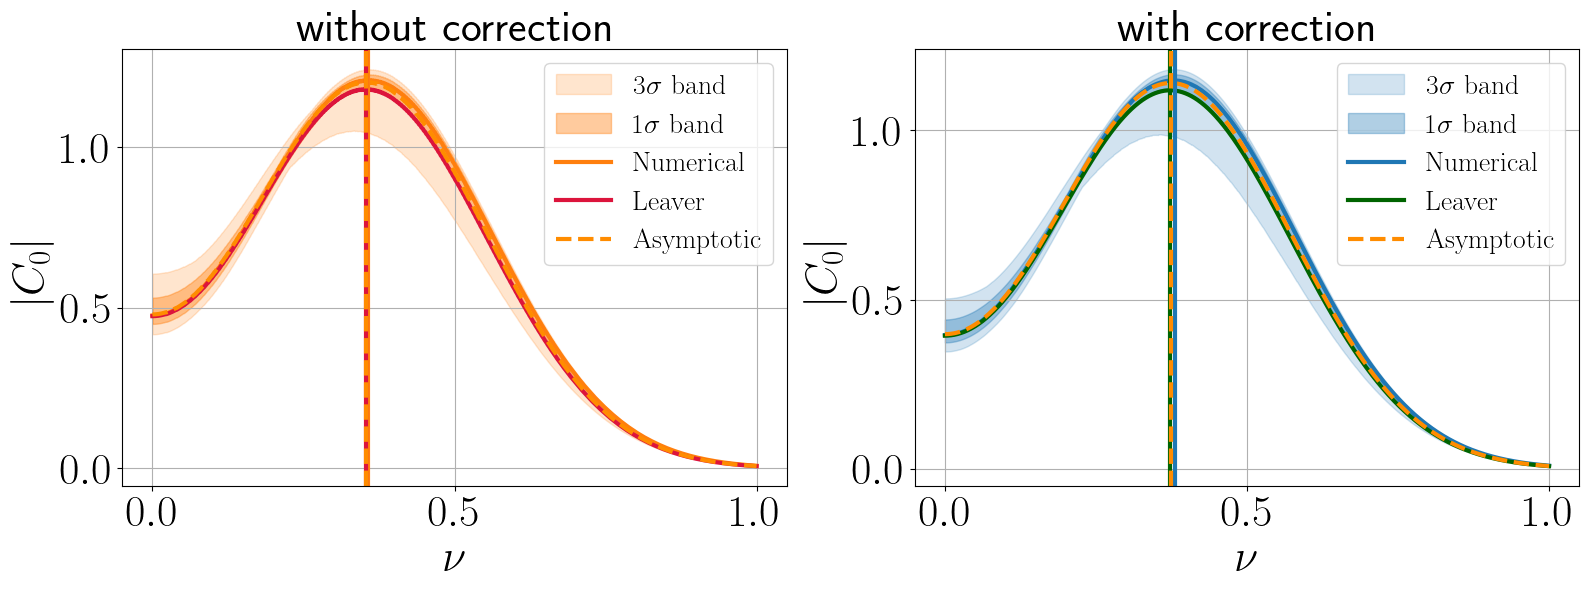

In [98]:
# parameters
nsigma_pad = 10.0
Nmax_leaver = 300
e_spin = 3.0
global_fac = -2.0

# excitation factors
B_list_l2 = np.array([
    1.269024e-1 + 2.031517e-2j,
    4.768259e-2 - 2.237546e-1j,
    -1.902843e-1 + 1.574857e-2j,
    8.086762e-2 + 7.961260e-2j,
], dtype=complex)

B_used_l2 = B_list_l2[:N_modes_l2]

# effective truncation counter
N_effective_global = []

# geometric grid
s_grid = np.linspace(x_min, x_max, Ngrid)
ds_grid = s_grid[1] - s_grid[0]
r_areal = rw.r_of_s(s_grid, M=Mbh)
r_obs_areal = rw.r_of_s(np.array([r_obs_target_l2]), M=Mbh)[0]

# ============================================================
# leaver coefficients
# ============================================================
def leaver_an_coeffs_l2(omega, l, M=1.0, e=e_spin, Nmax=Nmax_leaver):
    global N_effective_global
    omega_bar = 2.0 * M * complex(omega)
    p = -1j * omega_bar

    def alpha(n):
        return n*n + (2*p + 2)*n + (2*p + 1)

    def beta(n):
        return -(2*n*n + (8*p + 2)*n + 8*p*p + 4*p + l*(l+1) - e)

    def gamma(n):
        return n*n + 4*p*n + 4*p*p - e - 1

    a = np.zeros(Nmax + 2, dtype=complex)
    a[Nmax] = 1.0

    for n in range(Nmax, 0, -1):
        a[n-1] = -(beta(n)*a[n] + alpha(n)*a[n+1]) / gamma(n)

    tol = 1e-14
    nz = np.where(np.abs(a) > tol)[0]

    if len(nz) > 0:
        N_used = nz[-1]
    else:
        N_used = 0

    N_effective_global.append(N_used)

    return a[:Nmax+1] / a[0]

# ============================================================
# normalized radial solution
# ============================================================
def psi_leaver_norm_l2(omega, r_areal_pts):
    r_bar = np.asarray(r_areal_pts) / (2*Mbh)
    z = 1.0 - 1.0/r_bar
    a = leaver_an_coeffs_l2(omega, l_mode_l2, Mbh)
    Sz = np.zeros_like(z, dtype=complex)

    for an in a[::-1]:
        Sz = Sz*z + an

    S1 = np.sum(a)
    p = -1j * (2*Mbh*omega)

    return np.exp((2*p)*np.log(z)) * (Sz / S1)

# ============================================================
# initial data
# ============================================================
def build_initial_data_for_leaver_l2(sigma, nu):
    f = A_init_l2 * np.exp(-(s_grid - r0_l2)**2 / (2*sigma**2)) * np.cos(nu * (s_grid - r0_l2))
    g = rw.d1_4th(f, ds_grid)
    mask = ((s_grid >= r0_l2 - nsigma_pad*sigma) & (s_grid <= r0_l2 + nsigma_pad*sigma))

    return s_grid[mask], r_areal[mask], f[mask], g[mask]

# ============================================================
# theoretical coefficients
# ============================================================
def compute_Cn_theoretical_l2(sigma, nu, t_peak):
    C_leaver = np.zeros(N_modes_l2, dtype=complex)
    C_asymp = np.zeros(N_modes_l2, dtype=complex)

    s_int, r_int, f_int, g_int = build_initial_data_for_leaver_l2(sigma, nu)

    for n, om in enumerate(omegas_l2):
        q = 1j * om * f_int - g_int
        psi_int = psi_leaver_norm_l2(om, r_int)
        exp_term = np.exp(1j * om * s_int)

        I_leaver = np.trapz(exp_term * psi_int * q, s_int)
        I_asymp = np.trapz(exp_term * q, s_int)

        phase = np.exp(-1j * om * (t_peak - r0_l2))

        C_leaver[n] = global_fac * B_used_l2[n] * I_leaver * phase
        C_asymp[n] = global_fac * B_used_l2[n] * I_asymp * phase

    return C_leaver, C_asymp

# ============================================================
# with correction
# ============================================================
C_leaver_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)
C_asymp_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)

for i, nu in enumerate(nu_grid_l2):
    C_leaver_l2[i], C_asymp_l2[i] = compute_Cn_theoretical_l2(sigma_l2, nu, t_peak_ref)

# ============================================================
# without correction
# ============================================================
C_leaver_uncorr_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)
C_asymp_uncorr_l2 = np.zeros((n_nu_l2, N_modes_l2), dtype=complex)

for i, nu in enumerate(nu_grid_l2):
    t_peak_local = waveforms_l2[nu]['t_peak']
    C_leaver_uncorr_l2[i], C_asymp_uncorr_l2[i] = compute_Cn_theoretical_l2(sigma_l2, nu, t_peak_local)

print("\nwithout correction:")
print(f"  numerical   ν_max = {nu_max_num_u:.5f}")
print(f"  leaver      ν_max = {nu_max_leaver_u:.5f}")
print(f"  asymptotic  ν_max = {nu_max_asymp_u:.5f}")

print("\nwith correction:")
print(f"  numerical   ν_max = {nu_max_num:.5f}")
print(f"  leaver      ν_max = {nu_max_leaver:.5f}")
print(f"  asymptotic  ν_max = {nu_max_asymp:.5f}")

# ============================================================
# final figure
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# without correction
ax = axes[0]
h_3s_u = ax.fill_between(nu_grid_l2, p3s_lo_uncorr, p3s_hi_uncorr, color='C1', alpha=0.20)
h_1s_u = ax.fill_between(nu_grid_l2, p1s_lo_uncorr, p1s_hi_uncorr, color='C1', alpha=0.40)
h_num_u, = ax.plot(nu_grid_l2, median_C0_uncorr, color='C1', lw=3)
h_leaver_u, = ax.plot(nu_grid_l2, np.abs(C_leaver_uncorr_l2[:, 0]), color='crimson', lw=3)
h_asymp_u, = ax.plot(nu_grid_l2, np.abs(C_asymp_uncorr_l2[:, 0]), color='darkorange', lw=3, ls='--')

nu_max_num_u = nu_grid_l2[np.nanargmax(median_C0_uncorr)]
nu_max_leaver_u = nu_grid_l2[np.nanargmax(np.abs(C_leaver_uncorr_l2[:, 0]))]
nu_max_asymp_u = nu_grid_l2[np.nanargmax(np.abs(C_asymp_uncorr_l2[:, 0]))]

ax.axvline(nu_max_num_u, color='C1', lw=3)
ax.axvline(nu_max_leaver_u, color='crimson', lw=3)
ax.axvline(nu_max_asymp_u, color='darkorange', lw=3, ls='--')

handles_u = [h_3s_u, h_1s_u, h_num_u, h_leaver_u, h_asymp_u]
labels_u = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles_u, labels_u, fontsize=20, frameon=True, loc='upper right')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$|C_0|$', fontsize=32)
ax.set_title(r'without correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

# with correction
ax = axes[1]
h_3s = ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2, color='C0', alpha=0.20)
h_1s = ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2, color='C0', alpha=0.35)
h_num, = ax.plot(nu_grid_l2, median_C0_l2, color='C0', lw=3)
h_leaver, = ax.plot(nu_grid_l2, np.abs(C_leaver_l2[:, 0]), color='darkgreen', lw=3)
h_asymp, = ax.plot(nu_grid_l2, np.abs(C_asymp_l2[:, 0]), color='darkorange', lw=3, ls='--')

nu_max_num = nu_grid_l2[np.nanargmax(median_C0_l2)]
nu_max_leaver = nu_grid_l2[np.nanargmax(np.abs(C_leaver_l2[:, 0]))]
nu_max_asymp = nu_grid_l2[np.nanargmax(np.abs(C_asymp_l2[:, 0]))]

ax.axvline(nu_max_num, color='C0', lw=3)
ax.axvline(nu_max_leaver, color='darkgreen', lw=3)
ax.axvline(nu_max_asymp, color='darkorange', lw=3, ls='--')

handles = [h_3s, h_1s, h_num, h_leaver, h_asymp]
labels = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles, labels, fontsize=20, frameon=True, loc='upper right')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$|C_0|$', fontsize=32)
ax.set_title(r'with correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

plt.tight_layout()
plt.show()

### Phases

We now compare the phase of the numerical QNM amplitudes with the theoretical predictions obtained from the Leaver solution and the asymptotic approximation. The phases are unwrapped and aligned modulo $2\pi$ before comparison.


without correction:
  numerical   = -2.27776
  leaver      = -2.14601
  asymptotic  = -2.22616

with correction:
  numerical   = -2.47058
  leaver      = -2.33884
  asymptotic  = -2.41898


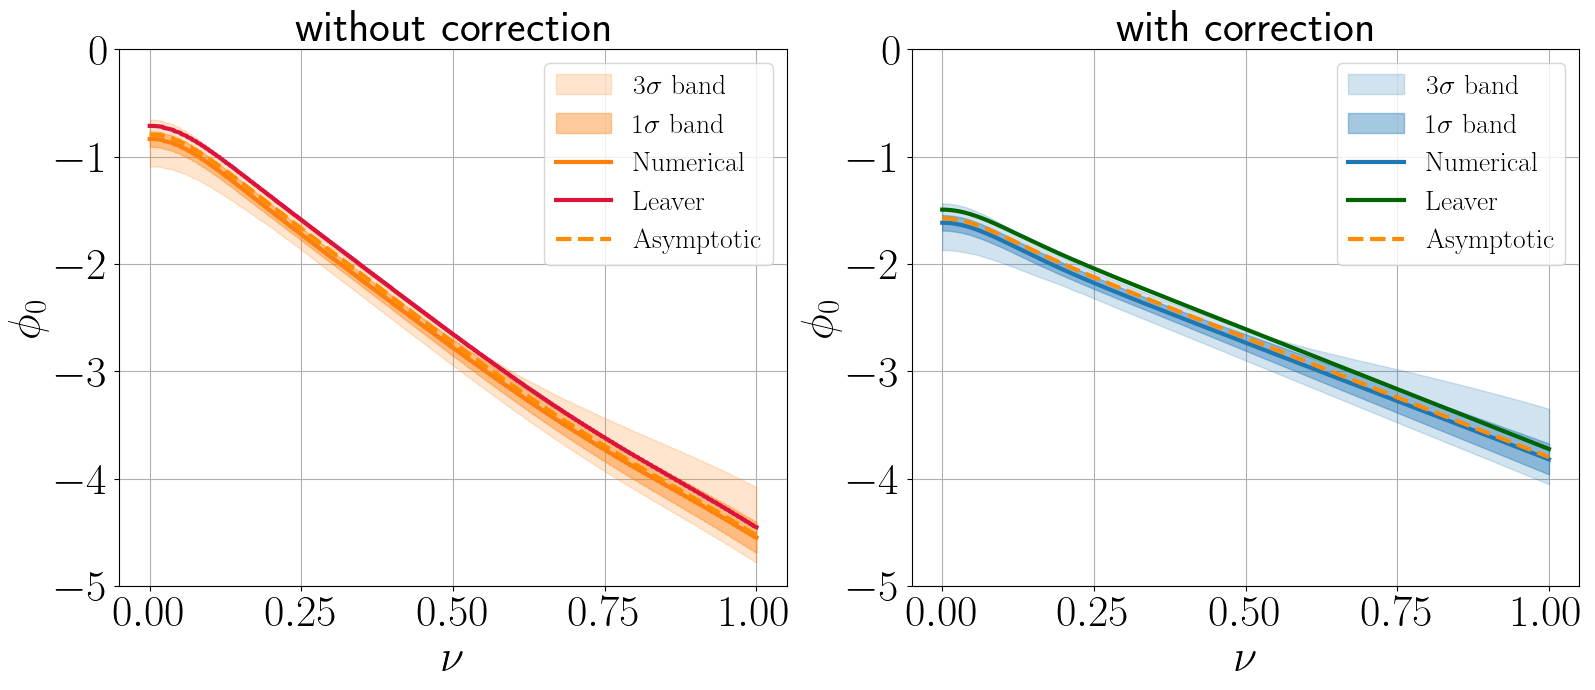

In [102]:
# corrected phases
phi_leaver = np.angle(C_leaver_l2[:, 0])
phi_asymp = np.angle(C_asymp_l2[:, 0])

phi_leaver_uw = np.unwrap(phi_leaver)
phi_asymp_uw = np.unwrap(phi_asymp)

# uncorrected phases
phi_leaver_uncorr = np.angle(C_leaver_uncorr_l2[:, 0])
phi_asymp_uncorr = np.angle(C_asymp_uncorr_l2[:, 0])

phi_leaver_uncorr_uw = np.unwrap(phi_leaver_uncorr)
phi_asymp_uncorr_uw = np.unwrap(phi_asymp_uncorr)

# alignment modulo 2pi
def align_2pi(target, reference):
    diff = reference[0] - target[0]
    n_2pi = np.round(diff / (2*np.pi))
    return target + 2*np.pi*n_2pi

# corrected
phi_leaver_uw = align_2pi(phi_leaver_uw, phase_stats_l2_uw['med'])
phi_asymp_uw = align_2pi(phi_asymp_uw, phase_stats_l2_uw['med'])

# uncorrected
phi_leaver_uncorr_uw = align_2pi(phi_leaver_uncorr_uw, phase_stats_uncorr_uw['med'])
phi_asymp_uncorr_uw = align_2pi(phi_asymp_uncorr_uw, phase_stats_uncorr_uw['med'])

# diagnostics
idx_peak = np.nanargmax(median_C0_l2)

print("\nwithout correction:")
print(f"  numerical   = {phase_stats_uncorr_uw['med'][idx_peak]:.5f}")
print(f"  leaver      = {phi_leaver_uncorr_uw[idx_peak]:.5f}")
print(f"  asymptotic  = {phi_asymp_uncorr_uw[idx_peak]:.5f}")

print("\nwith correction:")
print(f"  numerical   = {phase_stats_l2_uw['med'][idx_peak]:.5f}")
print(f"  leaver      = {phi_leaver_uw[idx_peak]:.5f}")
print(f"  asymptotic  = {phi_asymp_uw[idx_peak]:.5f}")

# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# without correction
ax = axes[0]

h_3s_u = ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p3s_lo'], phase_stats_uncorr_uw['p3s_hi'], color='C1', alpha=0.20, zorder=2)
h_1s_u = ax.fill_between(nu_grid_l2, phase_stats_uncorr_uw['p1s_lo'], phase_stats_uncorr_uw['p1s_hi'], color='C1', alpha=0.40, zorder=3)

h_num_u, = ax.plot(nu_grid_l2, phase_stats_uncorr_uw['med'], color='C1', lw=3, zorder=5)
h_leaver_u, = ax.plot(nu_grid_l2, phi_leaver_uncorr_uw, color='crimson', lw=3, zorder=6)
h_asymp_u, = ax.plot(nu_grid_l2, phi_asymp_uncorr_uw, color='darkorange', lw=3, ls='--', zorder=6)

handles_u = [h_3s_u, h_1s_u, h_num_u, h_leaver_u, h_asymp_u]
labels_u = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles_u, labels_u, fontsize=20, frameon=True, loc='best')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$\phi_0$', fontsize=32)
ax.set_title(r'without correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)
ax.set_ylim(-5, 0)

# with correction
ax = axes[1]

h_3s = ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p3s_lo'], phase_stats_l2_uw['p3s_hi'], color='C0', alpha=0.20, zorder=2)
h_1s = ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p1s_lo'], phase_stats_l2_uw['p1s_hi'], color='C0', alpha=0.40, zorder=3)

h_num, = ax.plot(nu_grid_l2, phase_stats_l2_uw['med'], color='C0', lw=3, zorder=5)
h_leaver, = ax.plot(nu_grid_l2, phi_leaver_uw, color='darkgreen', lw=3, zorder=6)
h_asymp, = ax.plot(nu_grid_l2, phi_asymp_uw, color='darkorange', lw=3, ls='--', zorder=6)

handles = [h_3s, h_1s, h_num, h_leaver, h_asymp]
labels = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles, labels, fontsize=20, frameon=True, loc='best')
ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$\phi_0$', fontsize=32)
ax.set_title(r'with correction', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)
ax.set_ylim(-5, 0)

plt.tight_layout()
plt.show()

## Final result

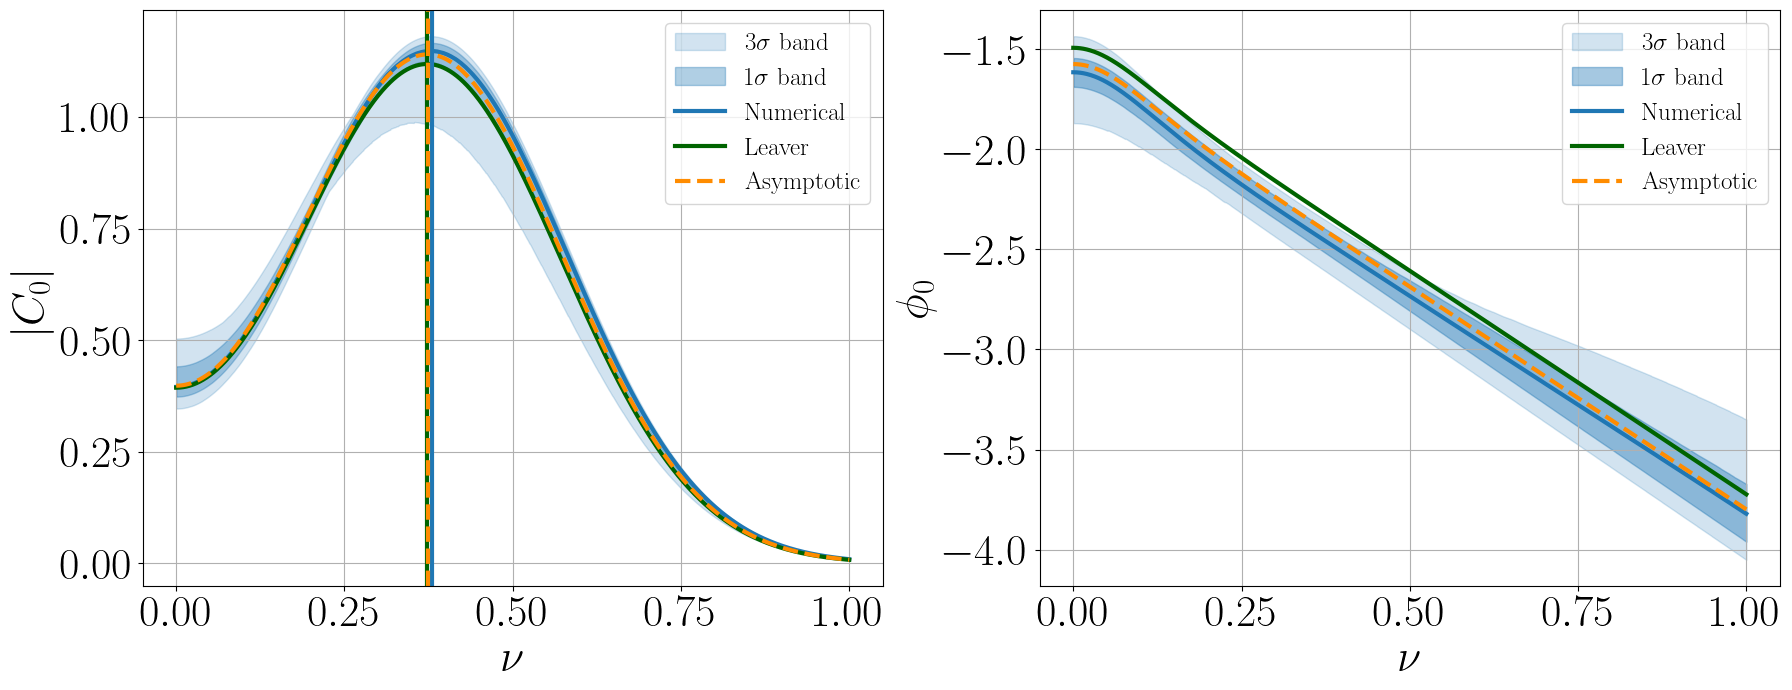

In [104]:
# ============================================================
# final figure
# ============================================================
plt.rcParams['text.usetex'] = True

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================
# amplitude
# ============================================================
ax = axes[0]

h_3s = ax.fill_between(nu_grid_l2, p3s_lo_l2, p3s_hi_l2, color='C0', alpha=0.20)
h_1s = ax.fill_between(nu_grid_l2, p1s_lo_l2, p1s_hi_l2, color='C0', alpha=0.35)

h_num, = ax.plot(nu_grid_l2, median_C0_l2, color='C0', lw=3)
h_leaver, = ax.plot(nu_grid_l2, np.abs(C_leaver_l2[:, 0]), color='darkgreen', lw=3)
h_asymp, = ax.plot(nu_grid_l2, np.abs(C_asymp_l2[:, 0]), color='darkorange', lw=3, ls='--')

nu_max_num = nu_grid_l2[np.nanargmax(median_C0_l2)]
nu_max_leaver = nu_grid_l2[np.nanargmax(np.abs(C_leaver_l2[:, 0]))]
nu_max_asymp = nu_grid_l2[np.nanargmax(np.abs(C_asymp_l2[:, 0]))]

ax.axvline(nu_max_num, color='C0', lw=3)
ax.axvline(nu_max_leaver, color='darkgreen', lw=3)
ax.axvline(nu_max_asymp, color='darkorange', lw=3, ls='--')

handles = [h_3s, h_1s, h_num, h_leaver, h_asymp]

labels = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles, labels, fontsize=18, frameon=True, loc='upper right')

ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$|C_0|$', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)

# ============================================================
# phase
# ============================================================
ax = axes[1]

h_3s_p = ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p3s_lo'], phase_stats_l2_uw['p3s_hi'], color='C0', alpha=0.20)
h_1s_p = ax.fill_between(nu_grid_l2, phase_stats_l2_uw['p1s_lo'], phase_stats_l2_uw['p1s_hi'], color='C0', alpha=0.40)

h_num_p, = ax.plot(nu_grid_l2, phase_stats_l2_uw['med'], color='C0', lw=3)
h_leaver_p, = ax.plot(nu_grid_l2, phi_leaver_uw, color='darkgreen', lw=3)
h_asymp_p, = ax.plot(nu_grid_l2, phi_asymp_uw, color='darkorange', lw=3, ls='--')

handles_p = [h_3s_p, h_1s_p, h_num_p, h_leaver_p, h_asymp_p]

labels_p = [
    r'$3\sigma$ $\mathrm{band}$',
    r'$1\sigma$ $\mathrm{band}$',
    r'$\mathrm{Numerical}$',
    r'$\mathrm{Leaver}$',
    r'$\mathrm{Asymptotic}$'
]

ax.legend(handles_p, labels_p, fontsize=18, frameon=True, loc='best')

ax.set_xlabel(r'$\nu$', fontsize=32)
ax.set_ylabel(r'$\phi_0$', fontsize=32)
ax.tick_params(labelsize=32)
ax.grid(True)
plt.tight_layout()
plt.show()